# Step 1: Business Problem
  **Detecting and Preventing Online Payment Fraud**

**Background:**
Online payment fraud is a significant challenge for financial institutions, fintech companies, and e-commerce platforms. Fraudsters use stolen credit cards, fake accounts, and other deceptive tactics to exploit online payment systems. If undetected, fraudulent transactions lead to financial losses, reputational damage, and reduced customer trust.

**Problem Statement:**
Traditional fraud detection methods rely on rule-based systems that struggle to keep up with evolving fraud patterns. The goal of this project is to develop a machine learning model that classifies transactions as fraudulent or legitimate, helping financial institutions detect fraud in real-time and minimize losses.


- Transaction Details: Amount, type, time, and payment method 💰
- User Behavior: Past fraud history, account age, recent activity 📊
- Device & Location: Device used, transaction location 🌍

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\divya\Downloads\Fraud Detection Dataset.csv")
df

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


In [4]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [6]:
df['Transaction_ID'].unique()

array(['T1', 'T2', 'T3', ..., 'T49998', 'T49999', 'T50000'],
      shape=(50000,), dtype=object)

In [7]:
df['Transaction_ID'].value_counts()

Transaction_ID
T21614    2
T10897    2
T12008    2
T1004     2
T5        2
         ..
T49996    1
T49997    1
T49998    1
T49999    1
T50000    1
Name: count, Length: 50000, dtype: int64

In [8]:
df['User_ID'].unique()

array([4174, 4507, 1860, ..., 4616, 2261, 4210], shape=(4000,))

In [9]:
df['User_ID'].value_counts()

User_ID
3134    28
1018    27
2573    26
4534    26
3773    26
        ..
2653     3
1423     3
3238     3
4378     3
1543     2
Name: count, Length: 4000, dtype: int64

In [10]:
df['Transaction_Amount'].unique()


array([1292.76, 1554.58, 2395.02, ...,  647.11, 2446.65, 2867.43],
      shape=(44822,))

In [11]:
df['Transaction_Amount'].value_counts()

Transaction_Amount
49997.80    508
3562.91       4
1747.31       4
2748.08       4
495.14        4
           ... 
623.00        1
1646.54       1
2395.02       1
857.66        1
4392.68       1
Name: count, Length: 44821, dtype: int64

In [12]:
df['Transaction_Type'].unique()

array(['ATM Withdrawal', 'Bill Payment', 'POS Payment', 'Bank Transfer',
       'Online Purchase'], dtype=object)

In [13]:
df['Transaction_Type'].value_counts()

Transaction_Type
Bill Payment       10340
Bank Transfer      10276
ATM Withdrawal     10164
POS Payment        10126
Online Purchase    10094
Name: count, dtype: int64

In [14]:
df['Time_of_Transaction'].unique()

array([16., 13., nan, 15., 19.,  2.,  3., 20.,  0., 12., 21., 14.,  7.,
        4., 17., 10.,  5.,  8., 11., 18.,  1., 22.,  9.,  6., 23.])

In [15]:
df['Time_of_Transaction'].value_counts()

Time_of_Transaction
18.0    2112
13.0    2087
15.0    2076
3.0     2071
17.0    2060
0.0     2045
5.0     2036
4.0     2035
11.0    2034
16.0    2032
8.0     2026
1.0     2025
21.0    2024
20.0    2014
2.0     2002
6.0     2000
22.0    1994
7.0     1981
12.0    1980
23.0    1979
14.0    1975
10.0    1971
19.0    1947
9.0     1942
Name: count, dtype: int64

In [16]:
df['Device_Used'].unique()

array(['Tablet', 'Mobile', 'Desktop', nan, 'Unknown Device'], dtype=object)

In [17]:
df['Device_Used'].value_counts()

Device_Used
Desktop           15795
Mobile            15614
Tablet            15588
Unknown Device     1530
Name: count, dtype: int64

In [18]:
df['Location'].unique()

array(['San Francisco', 'New York', nan, 'Chicago', 'Boston', 'Houston',
       'Miami', 'Los Angeles', 'Seattle'], dtype=object)

In [19]:
df['Location'].value_counts()

Location
Boston           6149
New York         6110
Seattle          6104
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
Name: count, dtype: int64

In [20]:
df['Previous_Fraudulent_Transactions'].unique()

array([0, 4, 3, 2, 1])

In [21]:
df['Previous_Fraudulent_Transactions'].value_counts()

Previous_Fraudulent_Transactions
2    10321
0    10280
4    10205
1    10131
3    10063
Name: count, dtype: int64

In [22]:
df['Account_Age'].unique()

array([119,  79, 115,   3,  57,  96,   6,  13, 110,  66,   4,  68,  25,
       113,  52,  65,  21,  61,  22,  43,   7, 103,   8,  71,  63,  99,
        81,  82,   2,  85,  14,  31, 108, 116,  15,  51,  46,  94,  93,
        70,  10,   1,  58, 112,  41,  27,  19,  35,  18, 106,  29, 109,
        16,  74,  28, 107,  78,  44,  77,  40,  20,  11,  50,  45, 114,
        37,  48,  30,  89,   9, 104,  67, 100, 117,  47,  38,  86,  34,
        80,  90,   5,  91,  42,  83,  49, 102,  54,  12,  72,  69,  23,
        36,  97,  76,  95,  33, 101,  59,  39, 105,  98,  56, 118,  62,
        84,  75,  92, 111,  32,  26,  64,  60,  24,  87,  73,  88,  55,
        17,  53])

In [23]:
df['Account_Age'].value_counts()

Account_Age
29     479
106    476
68     468
111    466
75     466
      ... 
97     394
64     390
14     385
42     384
12     382
Name: count, Length: 119, dtype: int64

In [24]:
df['Number_of_Transactions_Last_24H'].unique()

array([13,  3,  9,  4,  7, 14, 10, 12,  6,  1,  8,  2, 11,  5])

In [25]:
df['Number_of_Transactions_Last_24H'].value_counts()

Number_of_Transactions_Last_24H
5     3778
8     3756
7     3734
11    3683
13    3679
3     3652
4     3648
1     3623
10    3608
14    3602
6     3598
12    3573
2     3554
9     3512
Name: count, dtype: int64

In [26]:
df['Payment_Method'].unique()

array(['Debit Card', 'Credit Card', nan, 'UPI', 'Net Banking',
       'Invalid Method'], dtype=object)

In [27]:
df['Payment_Method'].value_counts()

Payment_Method
UPI               11887
Debit Card        11802
Net Banking       11666
Credit Card       11646
Invalid Method     1530
Name: count, dtype: int64

In [28]:
df['Fraudulent'].unique()


array([0, 1])

In [29]:
df['Fraudulent'].value_counts()

Fraudulent
0    48490
1     2510
Name: count, dtype: int64

In [30]:
48490/2510

19.318725099601593

In [31]:
df.drop(columns=['Transaction_ID','User_ID'], inplace=True)

In [32]:
Continous = ['Transaction_Amount','Time_of_Transaction','Number_of_Transactions_Last_24H','Account_Age','Previous_Fraudulent_Transactions']
Categorical = ['Device_Used','Payment_Method','Location','Transaction_Type','Fraudulent']

**Exploratory Data Analysis(EDA)**

  **for continous Variables**

In [34]:
df[Continous].describe()

,Transaction_Amount,Time_of_Transaction,Number_of_Transactions_Last_24H,Account_Age,Previous_Fraudulent_Transactions
count,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000
mean,2996.249784,11.488400,7.495588,60.033902,1.995725
std,5043.932555,6.922954,4.020080,34.384131,1.415150
min,5.030000,0.000000,1.000000,1.000000,0.000000
25%,1270.552500,5.000000,4.000000,30.000000,1.000000
50%,2524.100000,12.000000,7.000000,60.000000,2.000000
75%,3787.240000,17.000000,11.000000,90.000000,3.000000
max,49997.800000,23.000000,14.000000,119.000000,4.000000


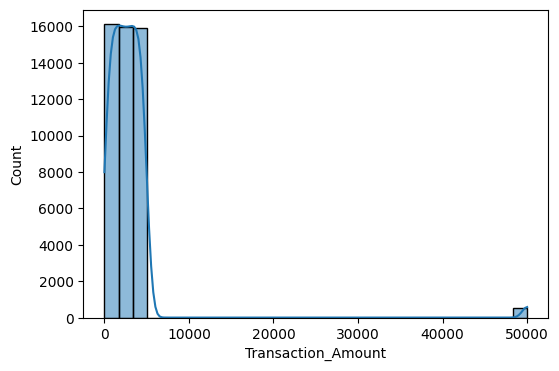

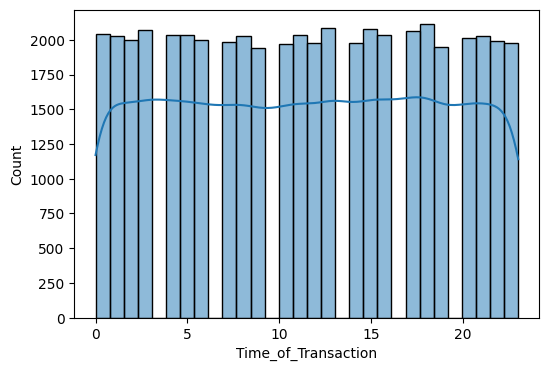

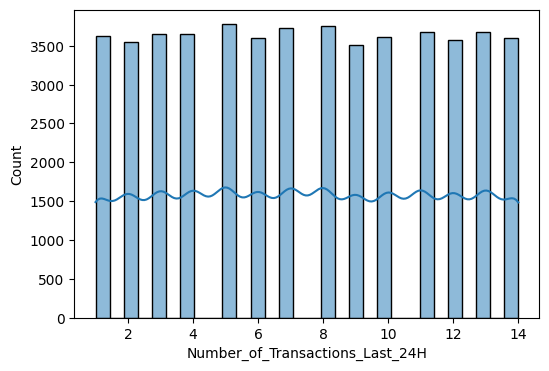

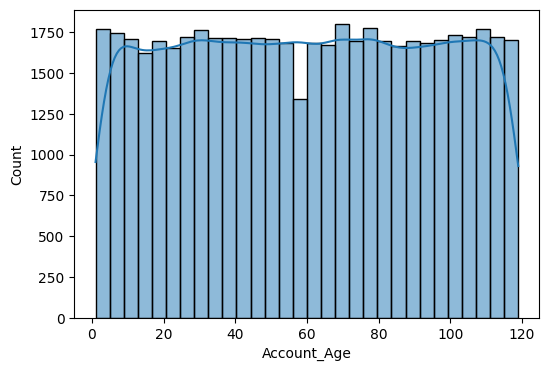

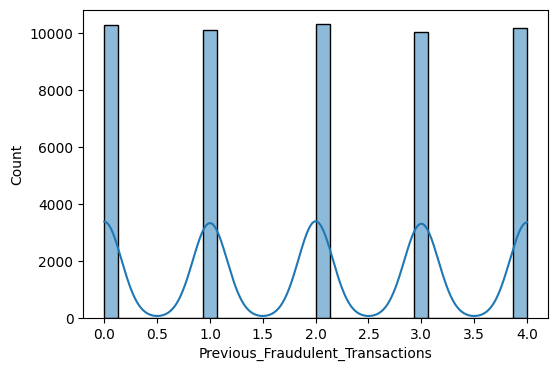

In [35]:
for i in Continous:
    plt.figure(figsize=(6,4))
    sns.histplot(df[i],kde=True,bins=30)
    plt.show()

In [36]:
df[Continous].skew()

Transaction_Amount                  8.454479
Time_of_Transaction                -0.004366
Number_of_Transactions_Last_24H     0.005220
Account_Age                        -0.002971
Previous_Fraudulent_Transactions    0.004440
dtype: float64

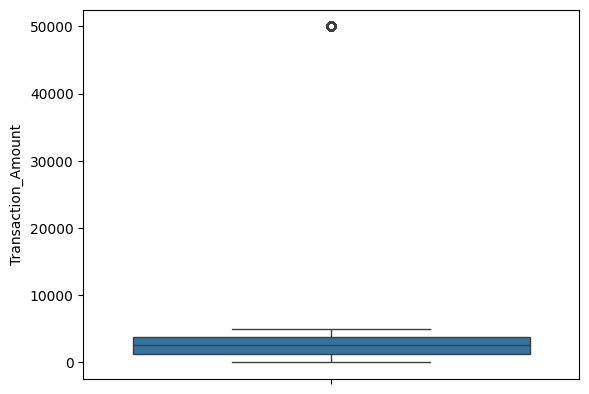

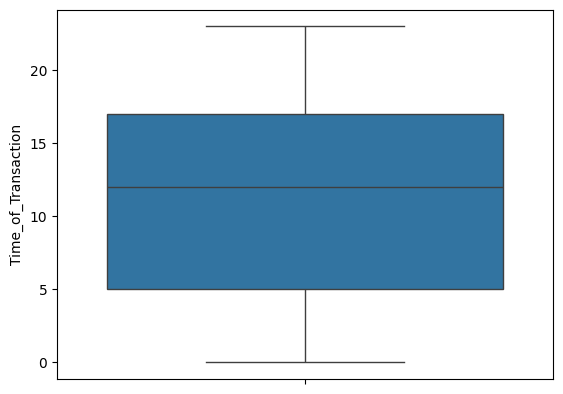

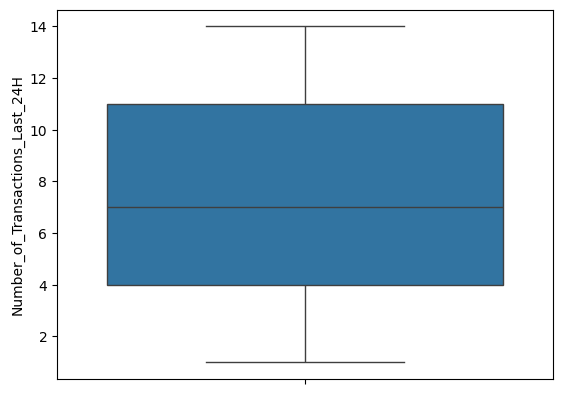

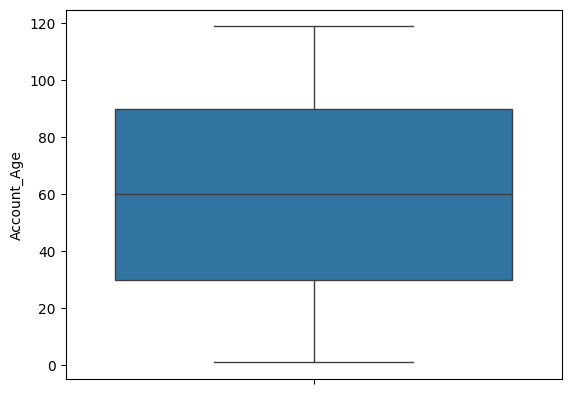

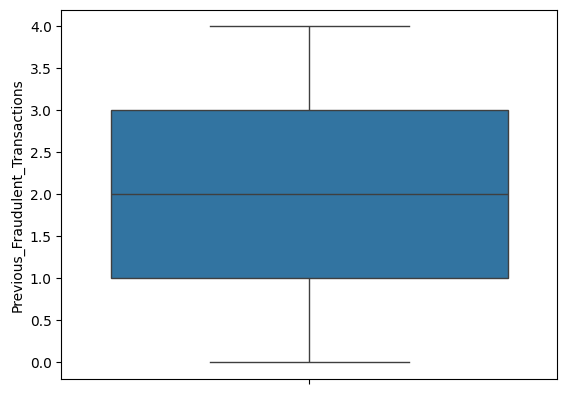

In [37]:
for i in Continous:
    sns.boxplot(df[i])
    plt.show()

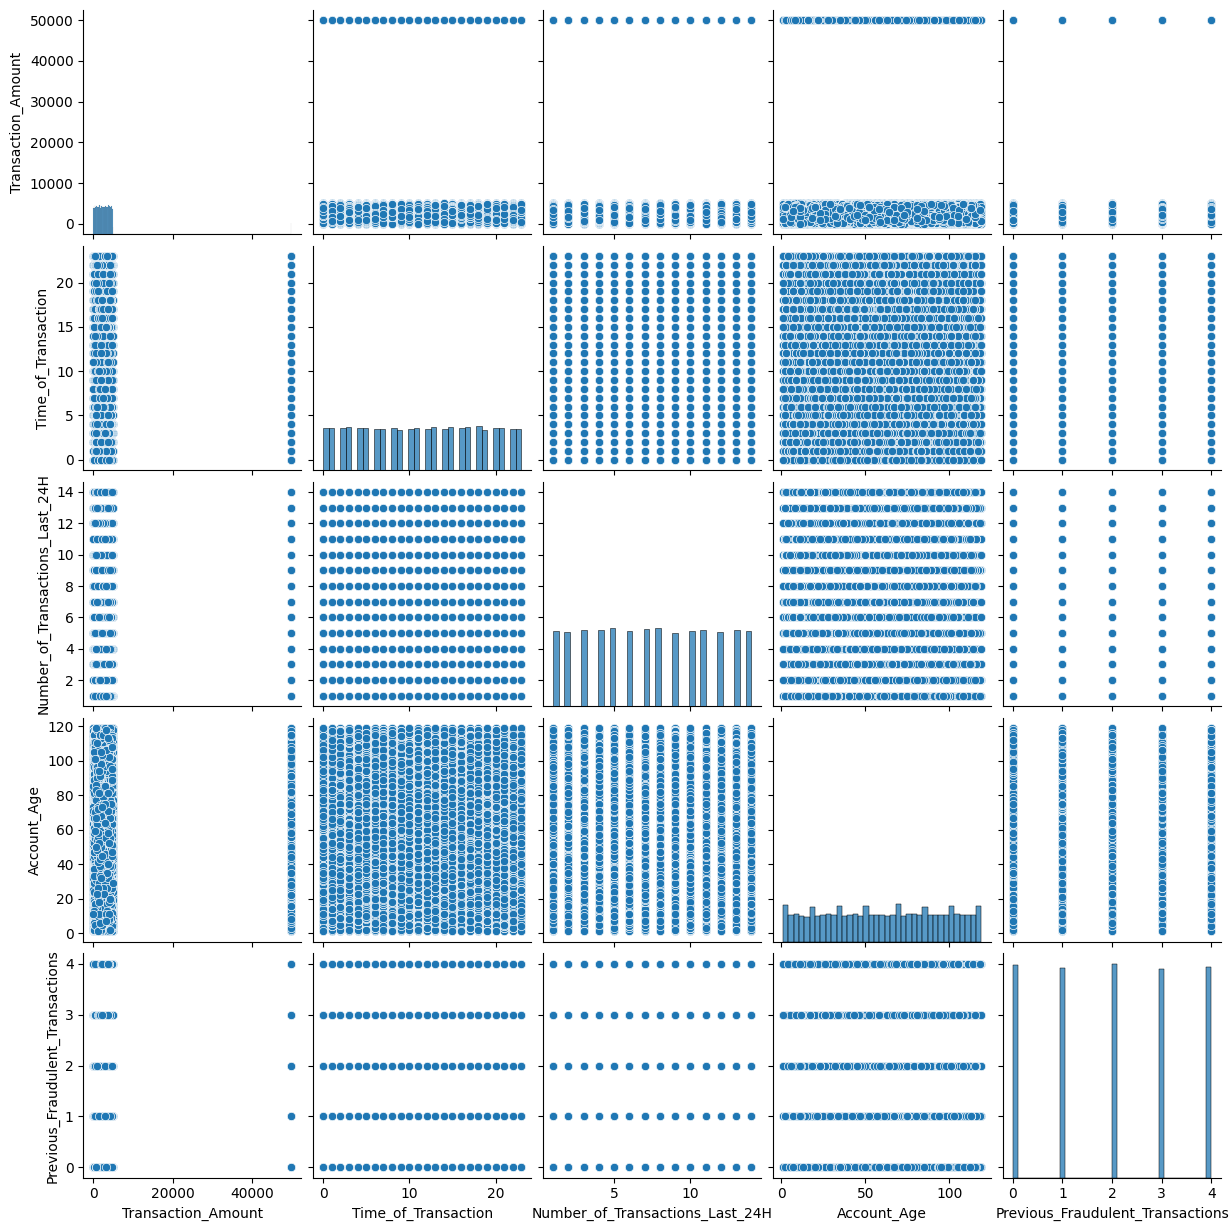

In [38]:
sns.pairplot(df[Continous])
plt.show()

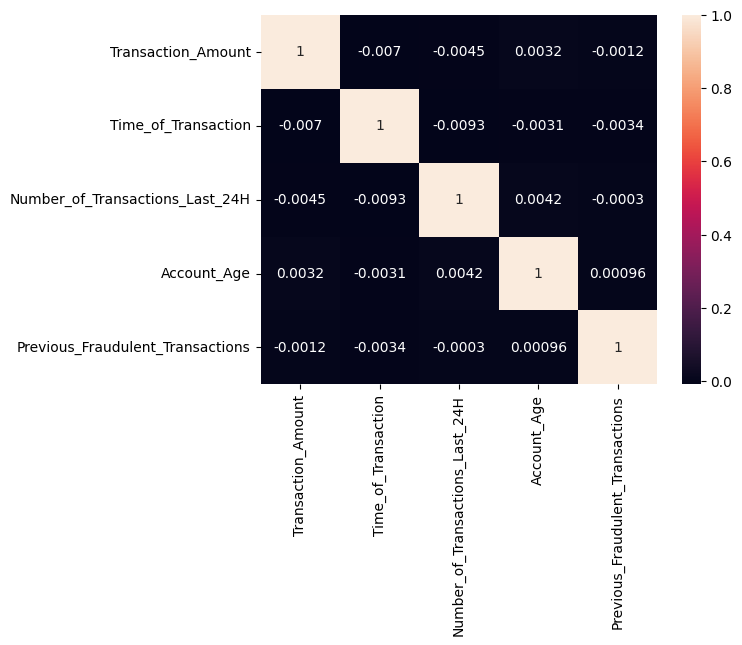

In [39]:
sns.heatmap(df[Continous].corr(),annot=True)
plt.show()

# Data Prepraration

**Missing Values Treatment**

In [42]:
df.isna().sum()

Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [43]:
df.isna().sum()/len(df)*100 

Transaction_Amount                  4.941176
Transaction_Type                    0.000000
Time_of_Transaction                 5.003922
Device_Used                         4.849020
Location                            4.994118
Previous_Fraudulent_Transactions    0.000000
Account_Age                         0.000000
Number_of_Transactions_Last_24H     0.000000
Payment_Method                      4.841176
Fraudulent                          0.000000
dtype: float64

In [44]:
df.duplicated().sum()

np.int64(881)

In [45]:
df.drop_duplicates()

,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...
50964,4187.49,Bank Transfer,4.0,Mobile,Chicago,2,67,13,NaN,0
50975,1826.49,POS Payment,10.0,Desktop,Houston,1,91,4,Net Banking,0
50985,544.53,Bank Transfer,14.0,Unknown Device,Chicago,4,59,12,Debit Card,0
50997,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0


In [46]:
# Impute categorical columns with the mode
df['Transaction_Type'].fillna(df['Transaction_Type'].mode()[0], inplace=True)
df['Device_Used'].fillna(df['Device_Used'].mode()[0], inplace=True)
df['Location'].fillna(df['Location'].mode()[0], inplace=True)
df['Payment_Method'].fillna(df['Payment_Method'].mode()[0], inplace=True)
df['Transaction_Amount'].fillna(df['Transaction_Amount'].median(), inplace=True)

# Impute numerical columns with the median
df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median(), inplace=True)
df['Account_Age'].fillna(df['Account_Age'].median(), inplace=True)


In [47]:
df['Location'].fillna('Unknown',inplace=True)
df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median(),inplace=True)

In [48]:
df.isna().sum()

Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [49]:
df[Continous].skew()

Transaction_Amount                  8.679972
Time_of_Transaction                -0.015837
Number_of_Transactions_Last_24H     0.005220
Account_Age                        -0.002971
Previous_Fraudulent_Transactions    0.004440
dtype: float64

In [50]:
from scipy.stats import boxcox
df['Transaction_Amount'], _ = boxcox(df['Transaction_Amount']+1)

**Encoding**

In [52]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [53]:
df = pd.get_dummies(df, columns=['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method'], drop_first=True)
df = df.astype(int)

In [54]:
df[Continous].skew()

Transaction_Amount                  0.264644
Time_of_Transaction                -0.015837
Number_of_Transactions_Last_24H     0.005220
Account_Age                        -0.002971
Previous_Fraudulent_Transactions    0.004440
dtype: float64

In [55]:
df.isna().sum()

Transaction_Amount                  0
Time_of_Transaction                 0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Fraudulent                          0
Transaction_Type_Bank Transfer      0
Transaction_Type_Bill Payment       0
Transaction_Type_Online Purchase    0
Transaction_Type_POS Payment        0
Device_Used_Mobile                  0
Device_Used_Tablet                  0
Device_Used_Unknown Device          0
Location_Chicago                    0
Location_Houston                    0
Location_Los Angeles                0
Location_Miami                      0
Location_New York                   0
Location_San Francisco              0
Location_Seattle                    0
Payment_Method_Debit Card           0
Payment_Method_Invalid Method       0
Payment_Method_Net Banking          0
Payment_Method_UPI                  0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(882)

In [57]:
df.drop_duplicates()

,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,Transaction_Type_Online Purchase,Transaction_Type_POS Payment,...,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI
0,16,16,0,119,13,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,17,13,4,79,3,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,19,12,3,115,9,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,7,15,4,3,4,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,17,19,2,57,7,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50964,22,4,2,67,13,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
50975,18,10,1,91,4,0,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
50985,12,14,4,59,12,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
50997,18,18,3,73,5,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0


In [58]:
print(df.dtypes)  # Should show int for dummy columns



Transaction_Amount                  int64
Time_of_Transaction                 int64
Previous_Fraudulent_Transactions    int64
Account_Age                         int64
Number_of_Transactions_Last_24H     int64
Fraudulent                          int64
Transaction_Type_Bank Transfer      int64
Transaction_Type_Bill Payment       int64
Transaction_Type_Online Purchase    int64
Transaction_Type_POS Payment        int64
Device_Used_Mobile                  int64
Device_Used_Tablet                  int64
Device_Used_Unknown Device          int64
Location_Chicago                    int64
Location_Houston                    int64
Location_Los Angeles                int64
Location_Miami                      int64
Location_New York                   int64
Location_San Francisco              int64
Location_Seattle                    int64
Payment_Method_Debit Card           int64
Payment_Method_Invalid Method       int64
Payment_Method_Net Banking          int64
Payment_Method_UPI                

In [59]:
df.to_csv('Imbalance clean_data.csv',index=False)